In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")

In [14]:
from mtu_plots import graph_metrics_models_and_mtu
print(matplotlib.__version__)

3.6.3


In [15]:
DEBUG = True

In [16]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

# readable legend keys
id_to_readable = {
    "ideal": "Ideal",
    "content": "Content Filtering",
    "chaney_content": "Chaney's Content Filtering",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

social_results_to_readable = {
    "sr_results": "SR: 100%\nSN: 0%",
    "sr90_social10_results": "90%\n10%",
    "sr80_social20_results": "80%\n20%",
    "sr70_social30_results": "70%\n30%",
    "sr60_social40_results": "60%\n40%",
    "sr_social_results": "50%\n50%",
    "sr40_social60_results": "40%\n60%",
    "sr30_social70_results": "30%\n70%",
    "sr20_social80_results": "20%\n80%",
    "sr10_social90_results": "10%\n90%",
    "social_results": "1%\n99%",
}

pop_results_to_readable = {
    "sr_results": "SR: 100%\nPop: 0%",
    "sr75_pop25_results": "75%\n25%",
    "sr_pop_results": "50%\n50%",
    "sr25_pop75_results": "25%\n75%",
    "pop_results": "0%\n100%",
}

new_results_to_readable = {
    "sr_results": "SR: 100%\nNew: 0%",
    "sr75_new25_results": "75%\n25%",
    "sr_new_results": "50%\n50%",
    "sr25_new75_results": "25%\n75%",
    "new_results": "0%\n100%",
}

sr_pop_new_results_to_readable = {
    "sr_results": "SR: 100%\nPop: 0%\nNew: 0%",
    "sr90_pop5_new5_results": "90%\n5%\n5%",
    "sr80_pop10_new10_results": "80%\n10%\n10%",
    "sr70_pop15_new15_results": "70%\n15%\n15%",
    "sr60_pop20_new20_results": "60%\n20%\n20%",
    "sr50_pop25_new25_results": "50%\n25%\n25%",
    "sr40_pop30_new30_results": "40%\n30%\n30%",
    "sr30_pop35_new35_results": "30%\n35%\n35%",
    "sr20_pop40_new40_results": "20%\n40%\n40%",
    "sr10_pop45_new45_results": "10%\n45%\n45%",
    "pop_new_results": "0%\n50%\n50%",
}

metrics_to_readable = {
    "random_users_jaccard": "Jaccard Usuarios Random",
    "random_users_mean_dist": "Distancia Media Usuarios Random",
    "true_sim_users_jaccard": "Jaccard Usuarios Similares",
    "true_sim_users_mean_dist": "Distancia Media Usuarios Similares",
    "sim_user_jaccard": "Jaccard Usuarios Similares según SR",
    "sim_user_mean_dist": "Distancia Media Usuarios Similares según SR",
    "sim_user_jaccard_relative": "Jaccard Usuarios Similares según SR vs Jaccard en Ideal",
    "sim_user_mean_dist_relative": "Distancia Media Usuarios Similares según SR vs Distancia Media en Ideal",
    "inter_user_mean_dispersion": "Dispersión Inter-Usuario",
    "inter_user_diversity": "Diversidad Inter-Usuario (Varianza de Dispersión)",
    "intra_user_mean_dispersion": "Dispersión Intra-Usuario (Promedio entre Usuarios)",
    "intra_user_dispersion_variance": "Dispersión Intra-Usuario (Varianza entre Usuarios)",
    "intra_user_diversity": "Diversidad Intra-Usuario (Varianza de Dispersión por cada Usuario)",
    "anwar_fbe" : "Efecto Filter Bubble de Anwar (Diversidad Inter-Usuario / Diversidad Intra-Usuario)",
    "anwar_homogeneity": "Homogenización de Anwar (1 / sqrt(Diversidad Inter-Usuario^2 + Diversidad Intra-Usuario^2))",
    "mean_utility": "Utilidad por Usuario en cada iteración (Promedio entre Usuarios)", #debe haber una mejor forma de graficar esto sin que sea tan ruidoso
    #"mean_utility_increment", igual que mean_total_user_utility
    "var_utility": "Utilidad por Usuario en cada iteración (Varianza entre Usuarios)", #same as mean_utility. Resultados parecen valiosos pero son muy erraticos
    "mean_total_user_utility": "Utilidad acumulada Total por Usuario (Promedio entre Usuarios)",
    "var_total_user_utility": "Utilidad acumulada Total por Usuario (Varianza entre Usuarios)",
    "gini": "Índice de Gini de Popularidad de Ítems"
}

readable_labels = {
    "id_to_readable": id_to_readable,
    "x_axis_results_to_readable": new_results_to_readable,
    "metrics_to_readable": metrics_to_readable,
}

In [17]:
folder_paths = [
    "sr_results",
    "sr90_pop5_new5_results",
    "sr80_pop10_new10_results",
    "sr70_pop15_new15_results",
    "sr60_pop20_new20_results",
    "sr50_pop25_new25_results",
    "sr40_pop30_new30_results",
    "sr30_pop35_new35_results",
    "sr20_pop40_new40_results",
    "sr10_pop45_new45_results",
    "pop_new_results",
    ]

folder_paths = [
    "sr_results",
    "sr75_pop25_results",
    "sr_pop_results",
    "sr25_pop75_results",
    "pop_results",
    ]

folder_paths = [
    "sr_results",
    "sr75_new25_results",
    "sr_new_results",
    "sr25_new75_results",
    "new_results",
    ]

#folder_paths = [
#    "sr_results",
#    "sr90_social10_results",
#    "sr80_social20_results",
#    "sr70_social30_results",
#    "sr60_social40_results",
#    "sr_social_results",
#    "sr40_social60_results",
#    "sr30_social70_results",
#    "sr20_social80_results",
#    "sr10_social90_results",
#    "social_results",
#    ]
final_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name][folder_path] += np.array(metric_vals)[:,-1].tolist()

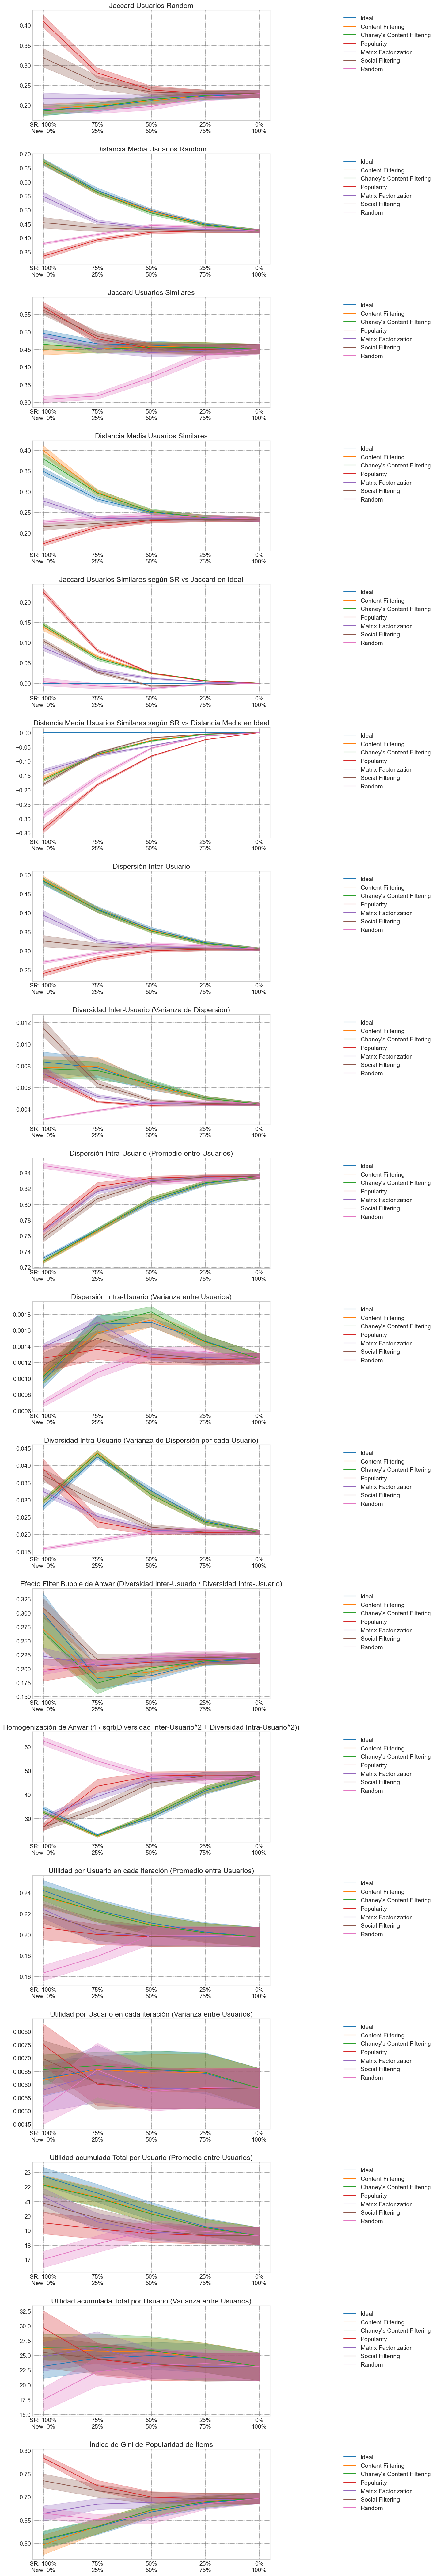

In [18]:
model_keys = [
    "ideal",
    "content",
    "chaney_content",
    "pop",
    "mf",
    "sf",
    "random"
]
metric_list = [
        "random_users_jaccard",
        "random_users_mean_dist",
        "true_sim_users_jaccard",
        "true_sim_users_mean_dist",
        #"sim_user_jaccard",
        #"sim_user_mean_dist",
        "sim_user_jaccard_relative",
        "sim_user_mean_dist_relative",
        "inter_user_mean_dispersion",
        "inter_user_diversity",
        "intra_user_mean_dispersion",
        "intra_user_dispersion_variance",
        "intra_user_diversity",
        "anwar_fbe",
        "anwar_homogeneity",
        "mean_utility", #debe haber una mejor forma de graficar esto sin que sea tan ruidoso
        #"mean_utility_increment", igual que mean_total_user_utility
        "var_utility", #same as mean_utility. Resultados parecen valiosos pero son muy erraticos
        "mean_total_user_utility",
        "var_total_user_utility",
        "gini"
        ]
graph_metrics_models_and_mtu(final_results, metric_list, model_keys, readable_labels, mult_sd=0.3, relative_to_ideal=False)
#plt.ylabel("Change in Jaccard Index")
#plt.xlabel("Timestep")
plt.legend(facecolor='white', framealpha=1, loc='upper right', bbox_to_anchor=(1.7, 1.0))
#plt.xlim(0, 100)
#plt.grid()
if not DEBUG:
    plt.savefig("figures/repeated_training_sim_pair.pdf", bbox_inches = "tight")